# Priprema podataka i izvedeni atributi

U ovoj svesci ćemo izgraditi atribute i sekvence prethodno odigranih mečeva, podeliti podatke hronološki i pripremiti tenzore za modele.

Pravilo koje važi za svaki atribut u ovoj svesci: vrednost za meč `g` sme da zavisi **isključivo** od mečeva odigranih strogo pre `g`. U praksi to znači obavezan `.shift(1)` pre svakog `.rolling(...)`.

Skup podataka se može preuzeti sa [ove](https://www.kaggle.com/datasets/nathanlauga/nba-games) adrese.

## Priprema

In [1]:
import sys
sys.path.append("..")

import joblib
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

import torch
from torch.utils.data import DataLoader

from src.config import (
    BATCH_SIZE,
    CONTEXT_CALENDAR_COLUMNS,
    LAST_TRAIN_SEASON,
    MODELS_PATH,
    PROCESSED_DATA_PATH,
    RANDOM_STATE,
    SEQUENCE_FEATURE_COLUMNS,
    SEQUENCE_LENGTH,
)
from src import data, features, sequences, plotting

# za deterministicko izvrsavanje sveske
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_STATE)

## Tabela iz ugla tima

In [2]:
df_games = data.clean_games(data.load_games())
df_games.shape

(24848, 18)

Čišćenje izbacuje pripremne mečeve, duplikate po `GAME_ID` i mečeve bez upisane statistike; preostaje tabela sortirana hronološki, spremna za prevođenje u tabelu iz ugla tima.

In [3]:
df_team_view = features.build_team_view(df_games)
df_team_view.head()

,GAME_ID,GAME_DATE_EST,SEASON,TEAM_ID,OPPONENT_TEAM_ID,IS_HOME,WON,PTS,FG_PCT,FT_PCT,FG3_PCT,AST,REB
0,20300006,2003-10-29,2003,1610612737,1610612740,0,0,83.0,0.398,0.737,0.214,18.0,58.0
1,20300024,2003-10-31,2003,1610612737,1610612741,0,0,94.0,0.400,0.714,0.583,22.0,48.0
2,20300029,2003-11-01,2003,1610612737,1610612754,1,0,99.0,0.468,0.677,0.375,23.0,36.0
3,20300042,2003-11-03,2003,1610612737,1610612740,1,1,90.0,0.427,0.652,0.333,20.0,50.0
4,20300060,2003-11-05,2003,1610612737,1610612744,0,0,72.0,0.367,0.500,0.333,19.0,43.0


Svaki meč sada daje dva reda - jedan iz ugla domaćina, jedan iz ugla gosta - sa istim skupom kolona (`PTS`, `FG_PCT`, `AST`, `REB`...) i oznakom `IS_HOME`.

## Pokretne statistike

In [4]:
df_team_view = features.add_rolling_stats(df_team_view)
df_team_view.filter(like="PTS").head()

,PTS,PTS_ROLLING_5,PTS_ROLLING_10
0,83.0,NaN,NaN
1,94.0,83.0,83.0
2,99.0,88.5,88.5
3,90.0,92.0,92.0
4,72.0,91.5,91.5


Svaka pokretna statistika koristi isključivo mečeve odigrane strogo pre trenutnog, zahvaljujući `.shift(1)` pre `.rolling(...)` - prvi meč svakog tima zato nema pokretni prosek (`NaN`).

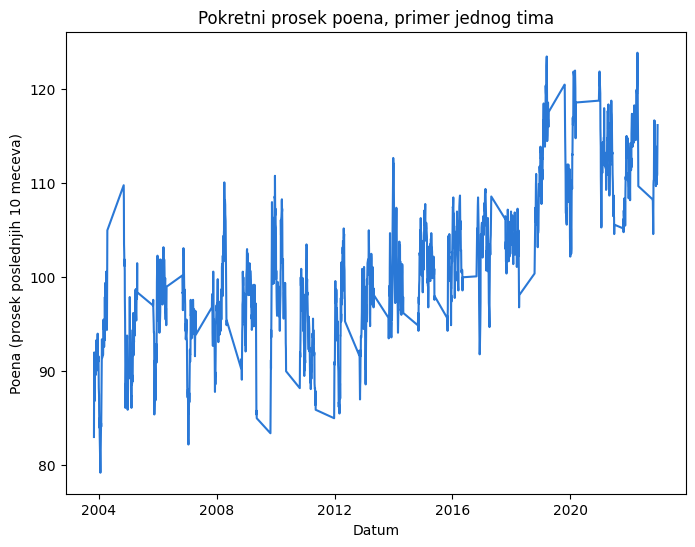

In [5]:
example_team = df_team_view["TEAM_ID"].iloc[0]
df_example = df_team_view[df_team_view["TEAM_ID"] == example_team]

plotting.new_figure(
    "Pokretni prosek poena, primer jednog tima",
    "Datum", "Poena (prosek poslednjih 10 meceva)",
)
plt.plot(df_example["GAME_DATE_EST"], df_example["PTS_ROLLING_10"], color=plotting.COLOR_HOME)
plt.show()

Pokretni prosek poena kroz sezone pokazuje uobičajeno variranje forme tima, bez naglih skokova koji bi ukazivali na grešku u računanju.

## Kalendarski atributi

In [6]:
df_team_view = features.add_calendar_features(df_team_view)
df_team_view[["REST_DAYS", "GAMES_LAST_7_DAYS", "IS_SEASON_START"]].describe()

,REST_DAYS,GAMES_LAST_7_DAYS,IS_SEASON_START
count,49666.000000,49696.000000,49696.000000
mean,4.216547,3.066223,0.012053
std,19.465265,0.873611,0.109125
min,1.000000,0.000000,0.000000
25%,2.000000,3.000000,0.000000
50%,2.000000,3.000000,0.000000
75%,2.000000,4.000000,0.000000
max,288.000000,5.000000,1.000000


`REST_DAYS` meri odmor od prethodnog meča, `GAMES_LAST_7_DAYS` gustinu rasporeda, a `IS_SEASON_START` obeležava prvi meč tima u sezoni - sve tri vrednosti su poznate unapred i ne traže `.shift(1)`.

## Elo rejting

*Funkciju `compute_elo` piše Jana.*

In [7]:
df_team_view = features.compute_elo(df_team_view)
df_team_view["ELO"].describe()

count    49696.000000
mean      1507.837257
std        102.163951
min       1187.493159
25%       1434.903649
50%       1509.146791
75%       1581.535596
max       1839.315360
Name: ELO, dtype: float64

Rejting kreće od `ELO_INITIAL` za svaki tim i ažurira se hronološki posle svakog meča standardnom Elo formulom, sa `ELO_HOME_BONUS` u računanju očekivanog ishoda i delimičnim vraćanjem ka proseku (`ELO_SEASON_REGRESSION`) na početku svake nove sezone, jer se sastavi timova menjaju. Kao atribut se koristi rejting **pre** meča - ažuriranje sledi tek pošto je taj rejting već zabeležen, pa je računanje po konstrukciji uzročno.

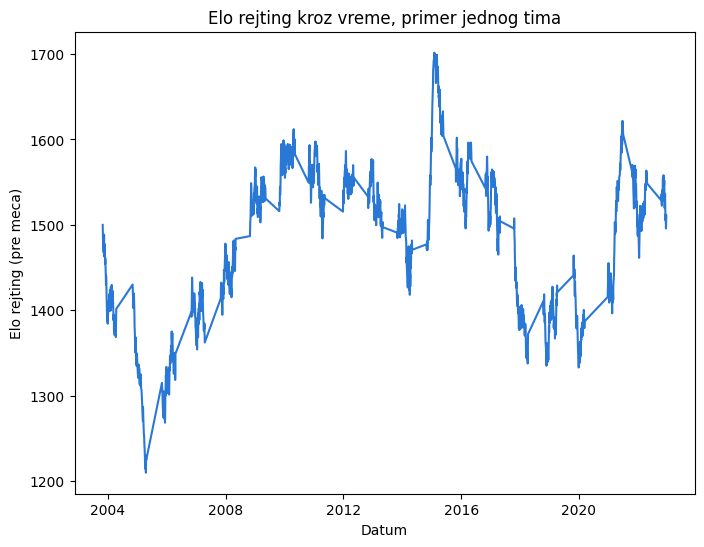

In [8]:
df_example = df_team_view[df_team_view["TEAM_ID"] == example_team]

plotting.new_figure(
    "Elo rejting kroz vreme, primer jednog tima",
    "Datum", "Elo rejting (pre meca)",
)
plt.plot(df_example["GAME_DATE_EST"], df_example["ELO"], color=plotting.COLOR_HOME)
plt.show()

Rejting oscilira sa formom tima unutar sezone, a na svakoj granici sezone vidljivo je vraćanje ka proseku od 1500 - tim koji je prethodnu sezonu završio veoma visoko ili veoma nisko sledeću počinje bliže proseku.

## Međusobni dueli

*Funkciju `add_head_to_head` piše Jana.*

In [9]:
df_team_view = features.add_head_to_head(df_team_view)
df_team_view["HEAD_TO_HEAD_WIN_PCT"].describe()

count    49696.000000
mean         0.500000
std          0.276008
min          0.000000
25%          0.250000
50%          0.500000
75%          0.750000
max          1.000000
Name: HEAD_TO_HEAD_WIN_PCT, dtype: float64

Procenat pobeda protiv **istog** protivnika u poslednjih `HEAD_TO_HEAD_GAMES` međusobnih duela, računat po istom obrascu kao pokretne statistike - `.shift(1)` pa `.rolling(...)` - tako da duel `g` zavisi isključivo od ranijih duela sa tim istim protivnikom. Parovi timova koji se dosad nisu sreli nemaju vrednost (`NaN`).

## Stanje na tabeli

Datoteka `ranking.csv` je snimak stanja na tabeli **po danu**, pa spajanje stanja sa datumom strogo pre meča daje legitimne pred-mečevske atribute — procenat pobeda i učinak kod kuće odnosno u gostima.

Kolone `HOME_RECORD` i `ROAD_RECORD` su tekst oblika `28-8` i rastavljaju se na dva broja.

*Funkciju `add_standings_features` piše Jana.*

In [10]:
df_rankings = data.load_rankings()
df_team_view = features.add_standings_features(df_team_view, df_rankings)
df_team_view[["STANDINGS_WIN_PCT", "STANDINGS_HOME_WIN_PCT", "STANDINGS_ROAD_WIN_PCT"]].describe()

,STANDINGS_WIN_PCT,STANDINGS_HOME_WIN_PCT,STANDINGS_ROAD_WIN_PCT
count,49696.000000,49696.000000,49696.000000
mean,0.504540,0.594532,0.423750
std,0.189116,0.209484,0.205162
min,0.000000,0.000000,0.000000
25%,0.385000,0.466667,0.285714
50%,0.509000,0.605263,0.428571
75%,0.634000,0.740741,0.555556
max,1.000000,1.000000,1.000000


Stanje se spaja sa najskorijim `STANDINGSDATE` strogo pre datuma meča, u okviru iste sezone i istog tima - spajanje preko sezone sprečava da prvi mečevi nove sezone preuzmu zastarelo stanje sa kraja prethodne, koje više ne važi jer se tabela svake sezone resetuje. Koriste se samo snimci iz regularnog dela sezone, iz istog razloga zbog kog se pripremni mečevi izbacuju u `clean_games`. `HOME_RECORD` i `ROAD_RECORD` (tekst oblika `28-8`) se rastavljaju na procenat pobeda kod kuće i procenat pobeda u gostima. Prvi mečevi svake sezone, pre nego što je ijedan snimak stanja objavljen, nemaju vrednost.

## Skaliranje

`StandardScaler` se trenira isključivo na trening sezonama (`SEASON <= LAST_TRAIN_SEASON`), pa se istim skalerom transformiše cela tabela. Skaliranje ide pre građenja sekvenci, tako da i sekvence i kontekst ispadnu već skalirani istim skalerom.

In [11]:
df_team_view_train = df_team_view[df_team_view["SEASON"] <= LAST_TRAIN_SEASON]
scaler = sequences.fit_scaler(df_team_view_train)
df_team_view[sequences.SCALED_COLUMNS] = scaler.transform(df_team_view[sequences.SCALED_COLUMNS])

# opisna statistika bas nad trening redovima, da potvrdimo da je scaler
# treniran na njima - ne nad celom tabelom, jer kasnije sezone imaju
# drugaciji stil igre pa im prosek posle skaliranja nece biti nula
df_team_view.loc[df_team_view_train.index, sequences.SCALED_COLUMNS].describe().loc[["mean", "std"]]

,PTS,FG_PCT,FT_PCT,FG3_PCT,AST,REB,WON,IS_HOME,REST_DAYS,GAMES_LAST_7_DAYS,IS_SEASON_START,ELO,HEAD_TO_HEAD_WIN_PCT,HEAD_TO_HEAD_WIN_PCT_MISSING,STANDINGS_WIN_PCT,STANDINGS_WIN_PCT_MISSING,STANDINGS_HOME_WIN_PCT,STANDINGS_HOME_WIN_PCT_MISSING,STANDINGS_ROAD_WIN_PCT,STANDINGS_ROAD_WIN_PCT_MISSING
mean,-4.645404e-16,-2.981847e-16,2.511029e-16,-2.416865e-16,3.154480e-16,3.868554e-16,0.000000,0.000000,-1.835749e-17,2.365860e-16,1.189306e-17,5.524264e-16,2.511029e-17,-5.728285e-17,2.197150e-16,-7.846966e-18,1.004412e-16,6.120633e-17,-2.636580e-16,6.395277e-17
std,1.000014e+00,1.000014e+00,1.000014e+00,1.000014e+00,1.000014e+00,1.000014e+00,1.000014,1.000014,1.000014e+00,1.000014e+00,1.000014e+00,1.000014e+00,1.000014e+00,1.000014e+00,1.000014e+00,1.000014e+00,1.000014e+00,1.000014e+00,1.000014e+00,1.000014e+00


Trening kolone posle skaliranja imaju prosek blizu nule - tačno očekivano ponašanje `StandardScaler`-a nad podacima na kojima je treniran.

## Građenje sekvenci

In [12]:
home_sequences, away_sequences, context, labels, indices = sequences.build_sequences(
    df_team_view, df_games
)
home_sequences.shape, away_sequences.shape, context.shape, labels.shape

((24830, 10, 8), (24830, 10, 8), (24830, 24), (24830,))

Mečevi bez ijednog odigranog meča pre sebe (prvi meč tima u skupu) se izbacuju - sekvenca bi bila sva od nula i ne bi nosila signal. Kraće sekvence se popunjavaju nulama na početku, tako da poslednji vremenski korak uvek bude najskoriji stvarni meč.

## Hronološka podela

In [13]:
train, validation, test, anomaly = sequences.chronological_split(df_games, indices)
len(train), len(validation), len(test), len(anomaly)

(18092, 2624, 1323, 2314)

Podela je po sezonama iz `config.py`: trening do `LAST_TRAIN_SEASON`, validacija do `LAST_VALIDATION_SEASON`, test je tačno `TEST_SEASON`. Sezone iz `ANOMALY_SEASONS` (kovid) i `UNUSED_SEASONS` (nepotpuna sezona) ne ulaze ni u jedan od tri skupa - anomalne se posebno analiziraju u svesci 05.

In [14]:
dataset_train = sequences.MatchSequenceDataset(
    home_sequences[train], away_sequences[train], context[train], labels[train]
)
len(dataset_train)

18092

`MatchSequenceDataset` pakuje sekvence, kontekst i oznake u torch tenzore tipa `float32`, spreman za `torch.utils.data.DataLoader` u svesci 04.

## Provera na curenje podataka

In [15]:
sequences.assert_no_leakage(
    df_team_view,
    ["LAST_GAME_DATE", "LAST_HEAD_TO_HEAD_DATE", "STANDINGS_SOURCE_DATE"],
    "GAME_DATE_EST",
)
print("Provera prosla - nijedan atribut ne potice iz buducnosti.")

Provera prosla - nijedan atribut ne potice iz buducnosti.


Provera potvrđuje da je izvorni datum svakog atributa strogo pre datuma meča na koji se atribut odnosi: `LAST_GAME_DATE` pokriva pokretne statistike i Elo — obe se ažuriraju posle svakog odigranog meča, istim datumom, pa isti datum služi kao granica za obe. `LAST_HEAD_TO_HEAD_DATE` pokriva međusobne duele, a `STANDINGS_SOURCE_DATE` (datum snimka tabele koji je `merge_asof` iskoristio) stanje na tabeli. Ovo je formalni dokaz protiv curenja podataka, na koji se možemo pozvati na odbrani.

## Dataset i DataLoader

Modeli u PyTorch-u se ne treniraju pojedinačnim primerima nego paketićima, koje pravi `DataLoader`. Proveravamo da `MatchSequenceDataset` daje ono što `DataLoader` očekuje.

In [16]:
generator = torch.Generator().manual_seed(RANDOM_STATE)
loader_train = DataLoader(dataset_train, batch_size=BATCH_SIZE, shuffle=True, generator=generator)

len(loader_train), len(dataset_train) % BATCH_SIZE

(283, 44)

Epoha ima 283 paketića jer 18092 primera nije deljivo sa `BATCH_SIZE`; poslednji nosi preostala 44 primera. Zadato seme obezbeđuje isti redosled paketića pri svakom pokretanju sveske.

`shuffle=True` je ispravno uprkos hronološkoj podeli — meša se redosled primera unutar epohe, ne vreme unutar primera. Svaka sekvenca i dalje sadrži isključivo mečeve odigrane pre svog meča.

In [17]:
home_batch, away_batch, context_batch, label_batch = next(iter(loader_train))

home_batch.shape, away_batch.shape, context_batch.shape, label_batch.shape

(torch.Size([64, 10, 8]),
 torch.Size([64, 10, 8]),
 torch.Size([64, 24]),
 torch.Size([64]))

`Dataset` vraća jedan primer oblika `(10, 8)`, a `DataLoader` slaže `BATCH_SIZE` takvih primera duž nove nulte ose. Rekurentni slojevi u PyTorch-u podrazumevano očekuju obrnut redosled, `(timesteps, batch_size, N)`, pa se moraju praviti sa `batch_first=True` — inače bi veličinu paketića protumačili kao dužinu sekvence, bez ijedne poruke o grešci.

Kontekst nema vremensku osu: `REST_DAYS`, `GAMES_LAST_7_DAYS` i `IS_SEASON_START` opisuju meč koji se predviđa, a ne njegovu istoriju, pa se spajaju sa izlazom rekurentnog dela. Tri kolone za domaćina plus tri za gosta daju šest.

In [18]:
home_batch.dtype, label_batch.dtype

(torch.float32, torch.float32)

Oznake su realni brojevi, a ne celi, jer uobičajen gubitak za binarnu klasifikaciju u PyTorch-u, `BCEWithLogitsLoss`, traži cilj istog tipa i oblika kao izlaz modela.

In [19]:
n_features = len(SEQUENCE_FEATURE_COLUMNS)
n_context = 2 * len(CONTEXT_CALENDAR_COLUMNS)

assert home_batch.shape == (BATCH_SIZE, SEQUENCE_LENGTH, n_features)
assert away_batch.shape == home_batch.shape
assert context_batch.shape == (BATCH_SIZE, n_context)
assert label_batch.shape == (BATCH_SIZE,)
assert all(t.dtype == torch.float32 for t in (home_batch, away_batch, context_batch, label_batch))

Ove tvrdnje su zapis ugovora na koji se modeli oslanjaju. Ako neka padne, promena je u `sequences.py` i mora da se javi, a ne da se tiho zaobiđe na drugom mestu.

### Prazne vrednosti u tenzorima

Sanitarna provera iznad potvrđuje da nijedan atribut ne potiče iz budućnosti, ali ne kaže ništa o praznim vrednostima. To je druga vrsta greške i traži drugu proveru: `StandardScaler` propušta `NaN` bez upozorenja, a mreža ga pretvara u `nan` gubitak već u prvoj epohi.

In [20]:
context_column_names = [
    f"{side}_{name}" for side in ("HOME", "AWAY") for name in CONTEXT_CALENDAR_COLUMNS
]

pd.Series(np.isnan(context).sum(axis=0), index=context_column_names)

HOME_REST_DAYS                         0
HOME_GAMES_LAST_7_DAYS                 0
HOME_IS_SEASON_START                   0
HOME_ELO                               0
HOME_HEAD_TO_HEAD_WIN_PCT              0
HOME_HEAD_TO_HEAD_WIN_PCT_MISSING      0
HOME_STANDINGS_WIN_PCT                 0
HOME_STANDINGS_WIN_PCT_MISSING         0
HOME_STANDINGS_HOME_WIN_PCT            0
HOME_STANDINGS_HOME_WIN_PCT_MISSING    0
HOME_STANDINGS_ROAD_WIN_PCT            0
HOME_STANDINGS_ROAD_WIN_PCT_MISSING    0
AWAY_REST_DAYS                         0
AWAY_GAMES_LAST_7_DAYS                 0
AWAY_IS_SEASON_START                   0
AWAY_ELO                               0
AWAY_HEAD_TO_HEAD_WIN_PCT              0
AWAY_HEAD_TO_HEAD_WIN_PCT_MISSING      0
AWAY_STANDINGS_WIN_PCT                 0
AWAY_STANDINGS_WIN_PCT_MISSING         0
AWAY_STANDINGS_HOME_WIN_PCT            0
AWAY_STANDINGS_HOME_WIN_PCT_MISSING    0
AWAY_STANDINGS_ROAD_WIN_PCT            0
AWAY_STANDINGS_ROAD_WIN_PCT_MISSING    0
dtype: int32

Provera sada prolazi, ali nije oduvek prolazila: `GAMES_LAST_7_DAYS` je imao 859 praznih vrednosti. Uzrok je što za prozor zadat vremenskim rasponom pandas podrazumeva `min_periods=1`, pa kada je prethodni meč stariji od sedam dana — svaki prvi meč sezone — prozor je prazan i `count()` vraća `NaN` umesto nule. Ispravka je `min_periods=0` u `add_calendar_features`.

In [21]:
assert np.isnan(home_sequences).sum() == 0
assert np.isnan(away_sequences).sum() == 0
assert np.isnan(context).sum() == 0

### Poređenje modela zahteva isti skup mečeva

Metrike dva modela smeju da se porede samo ako su izmerene nad **istim mečevima**. Taj uslov je lako narušiti a teško primetiti, pa ga proveravamo ovde. Atributi koje sekvence ne koriste nisu svuda popunjeni:

In [22]:
extra_columns = ["ELO", "HEAD_TO_HEAD_WIN_PCT", "STANDINGS_WIN_PCT",
                 "STANDINGS_HOME_WIN_PCT", "STANDINGS_ROAD_WIN_PCT"]

df_team_view[extra_columns].isna().sum()

ELO                       0
HEAD_TO_HEAD_WIN_PCT      0
STANDINGS_WIN_PCT         0
STANDINGS_HOME_WIN_PCT    0
STANDINGS_ROAD_WIN_PCT    0
dtype: int64

Nijedna prazna vrednost nije greška — prvi duel protiv nekog protivnika stvarno nema istoriju, a tabela na početku sezone još ne postoji. Problem nastaje ako ih model ukloni sa `dropna()`, jer time menja skup na kom se meri.

In [23]:
# mec prezivi dropna samo ako oba tima imaju sve atribute
is_complete = df_team_view.groupby("GAME_ID")[extra_columns].apply(lambda g: g.notna().all().all())
test_game_ids = df_games.loc[indices[test], "GAME_ID"]

int((~is_complete.reindex(test_game_ids).fillna(False)).sum()), len(test_game_ids)

(0, 1323)

Gubitak nije nasumičan nego sistematski — odlaze mečevi s početka sezone, upravo oni koje je najteže predvideti. Model ocenjen nad preostalim mečevima dobija lakši skup i izgleda bolje iz razloga koji nema veze sa modelom, a razlika tog reda veličine uporediva je sa razlikom između samih modela.

Zato prazne vrednosti treba **popuniti, ne izbaciti**: 0.5 za procente pobeda, uz zasebnu zastavicu koja modelu kaže da je ta polovina „nema podatka", a ne izmerena ravnoteža.

## Čuvanje pripremljenih podataka

Skaler mora da preživi gašenje kernela: bez njega se sačuvani model ne može primeniti na nove mečeve, jer se ne zna kojim srednjim vrednostima i standardnim devijacijama su atributi skalirani.

In [24]:
MODELS_PATH.mkdir(parents=True, exist_ok=True)
joblib.dump(scaler, MODELS_PATH / "scaler.joblib")

print("scaler.joblib:", (MODELS_PATH / "scaler.joblib").stat().st_size // 1024, "KB")

scaler.joblib: 1 KB


Uz tenzore čuvamo i indekse podele. `indices` su oznake redova iz `df_games`, pa `train`, `validation` i `test` pokazuju na konkretne mečeve, a ne na apstraktne granice sezona — svaki model tako može da uzme identičan skup preko `df_games.loc[indices[test]]`, umesto da ponavlja `chronological_split` i rizikuje drugačiju podelu.

In [25]:
PROCESSED_DATA_PATH.mkdir(parents=True, exist_ok=True)
np.savez_compressed(
    PROCESSED_DATA_PATH / "sekvence.npz",
    home_sequences=home_sequences, away_sequences=away_sequences,
    context=context, labels=labels, indices=indices,
    train=train, validation=validation, test=test, anomaly=anomaly,
)

Građenje sekvenci prolazi kroz sve mečeve redom i traje oko minut i po, pa bi se bez ovog zapisa ponavljalo pri svakom pokretanju.

In [26]:
cache = np.load(PROCESSED_DATA_PATH / "sekvence.npz")

assert np.array_equal(cache["home_sequences"], home_sequences)
assert np.array_equal(cache["context"], context)
assert np.array_equal(cache["labels"], labels)
assert np.array_equal(cache["train"], train)

sorted(cache.files)

['anomaly',
 'away_sequences',
 'context',
 'home_sequences',
 'indices',
 'labels',
 'test',
 'train',
 'validation']

### Agregatni atributi za klasicne modele

Kontekstni vektor iznad je napravljen za mreze i ne sadrzi pokretne proseke
(`*_ROLLING_5`, `*_ROLLING_10`) - mreze ih ne trebaju, uce vremenski obrazac
same iz sirovih sekvenci. Logistickoj regresiji i XGBoost-u u svesci 03 treba
bas suprotno: gotovi, vec agregirani atributi, bez pristupa sirovoj istoriji.
Ta tabela dosad nije bila sacuvana - `df_team_view` je postojao samo u kernelu
ove sveske.

In [27]:
aggregate_features = features.build_aggregate_features(df_team_view, df_games, indices)
aggregate_features.shape

(24830, 52)

Jedan red po mecu, sa `HOME_`/`AWAY_` prefiksom po kolonama iz
`AGGREGATE_FEATURE_COLUMNS` - imena kolona ostaju citljiva radi tumacenja
koeficijenata logisticke regresije. Redovi su u istom poretku kao `indices`,
pa isti `train`/`validation`/`test`/`anomaly` nizovi vaze i ovde - klasicni
modeli i mreze se ocenjuju nad identicnim mecevima.

In [28]:
PROCESSED_DATA_PATH.mkdir(parents=True, exist_ok=True)
aggregate_features.to_csv(PROCESSED_DATA_PATH / "atributi.csv", index=False)

# poredjenje na priblizno jednako, ne .equals() - CSV je tekstualni format i
# ne cuva float64 do poslednjeg bita, za razliku od np.savez_compressed
cache = pd.read_csv(PROCESSED_DATA_PATH / "atributi.csv")
np.allclose(cache.to_numpy(), aggregate_features.to_numpy())

True

`data/processed/` se ne prati u git-u — i tenzori i `atributi.csv` se uvek mogu ponovo napraviti pokretanjem ove sveske. `models/scaler.joblib` **se prati**.

## Zaključak

U ovoj svesci smo tabelu mečeva preveli u tabelu iz ugla tima, dodali pokretne statistike, kalendarske atribute, Elo rejting, međusobne dvoboje i stanje na tabeli, skalirali izabrane kolone na trening skupu i sastavili sekvence poslednjih `SEQUENCE_LENGTH` mečeva za oba tima. Podela na trening, validaciju i test je hronološka, a sanitarna provera potvrđuje da nijedan atribut ne potiče iz budućnosti.

Elo, međusobni dueli i stanje na tabeli su sada deo `CONTEXT_CALENDAR_COLUMNS` i ulaze u kontekstni vektor koji `build_sequences` prosleđuje mrežama. Pokretni proseci ostaju van tog vektora - mreže uče vremenski obrazac same iz sirovih sekvenci - ali su, zajedno sa kontekstom, sačuvani posebno u `atributi.csv`, po meču, za logističku regresiju i XGBoost u svesci 03, koji rade nad istim, već agregiranim atributima umesto nad sirovom istorijom.

Sekvence, kontekst i oznake spremni su za `torch.utils.data.DataLoader`: jedan paketić daje tenzore oblika `(B, 10, 8)` za oba tima, `(B, 2 · len(CONTEXT_CALENDAR_COLUMNS))` za kontekst i `(B,)` za oznake, sve tipa `float32`. Provera je pokazala i da su prazne vrednosti u `GAMES_LAST_7_DAYS` dolazile od podrazumevanog `min_periods` u pomerajnom prozoru zadatom vremenom, što je ispravljeno u `add_calendar_features`.

Skaler je sačuvan u `models/`, a tenzori, agregatna tabela i indeksi podele u `data/processed/`. Indekse čuvamo da bi svi modeli mogli da se ocenjuju nad identičnim skupom mečeva — bez toga metrike različitih modela nisu uporedive.